In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
# 1. Load Data
df_busco = pd.read_csv('../data/busco_enterobacterales_table.tsv', sep='\t')

In [33]:
# Sort by Complete%
df_busco_sorted = df_busco.sort_values('Complete%', ascending=True)


In [35]:
# Prepare Data for Stacked Bar
# We need columns: 'Single%', 'Dup%', 'Frag%', 'Miss%'
plot_data = df_busco_sorted[['Sample', 'Single%', 'Dup%', 'Frag%', 'Miss%']].set_index('Sample')

Figure_BUSCO_StackedBar.png generated.


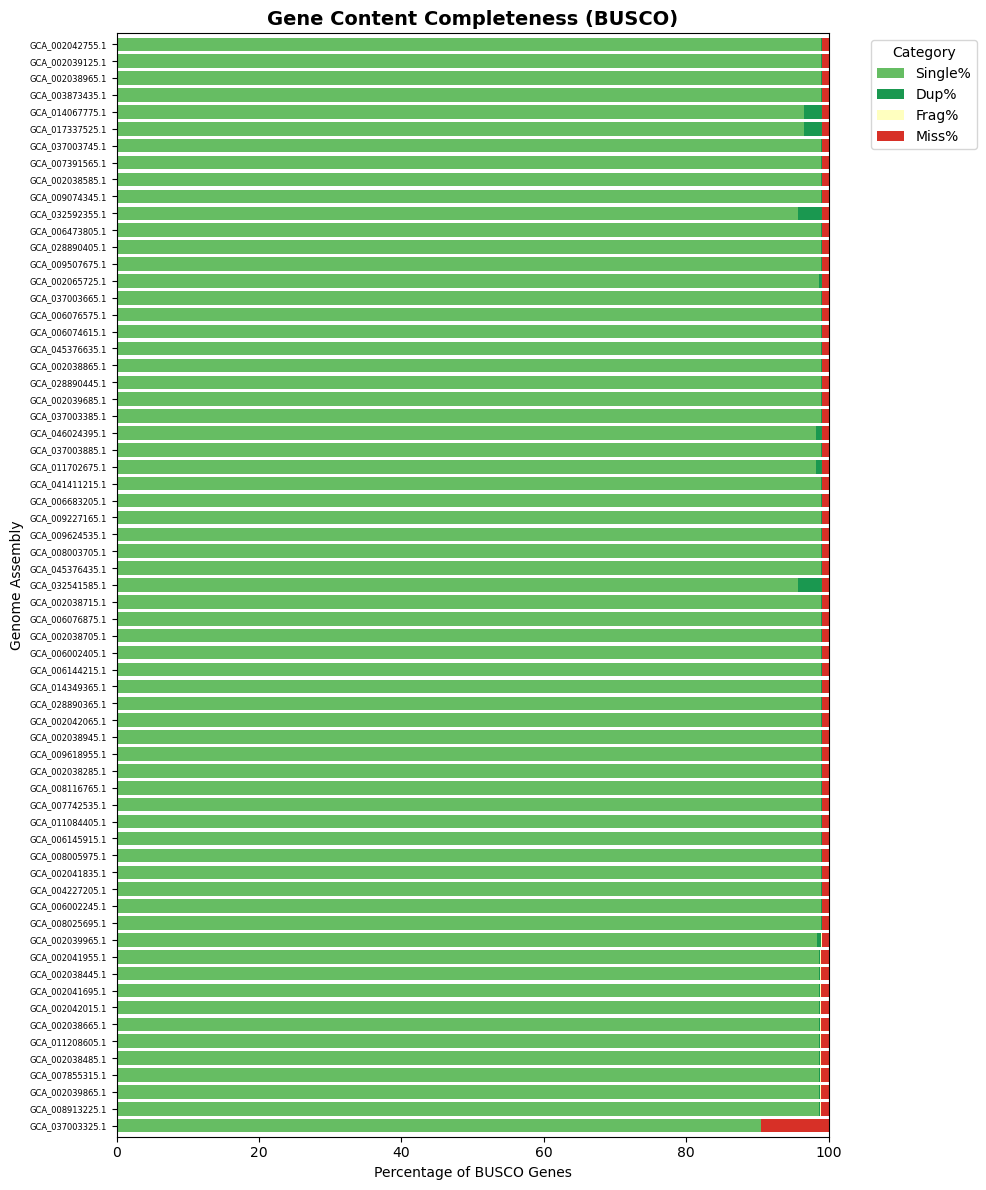

In [39]:
# Define BUSCO Standard Colors
busco_colors = {
    'Single%': '#66BD63', # Light Green
    'Dup%': '#1A9850',    # Dark Green
    'Frag%': '#FFFFBF',   # Yellow
    'Miss%': '#D73027'    # Red
}

# Plot
fig, ax = plt.subplots(figsize=(10, 12)) # Tall figure for 65 samples

plot_data.plot(
    kind='barh', 
    stacked=True, 
    color=[busco_colors[col] for col in plot_data.columns],
    width=0.8,
    ax=ax
)

ax.set_title('Gene Content Completeness (BUSCO)', fontsize=14, fontweight='bold')
ax.set_xlabel('Percentage of BUSCO Genes')
ax.set_ylabel('Genome Assembly')
ax.set_xlim(0, 100)
ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove Y-tick labels if too crowded (65 is a lot)
# But user might want to see them if they are looking for specific failures.
# Given they all passed, the names don't matter much.
# Let's keep them but make font small.
ax.tick_params(axis='y', labelsize=6)

plt.tight_layout()
plt.savefig('Figure_BUSCO_StackedBar.tiff', dpi=600)
print("Figure_BUSCO_StackedBar.png generated.")

Figure_BUSCO_Boxplot_Fixed.png generated.


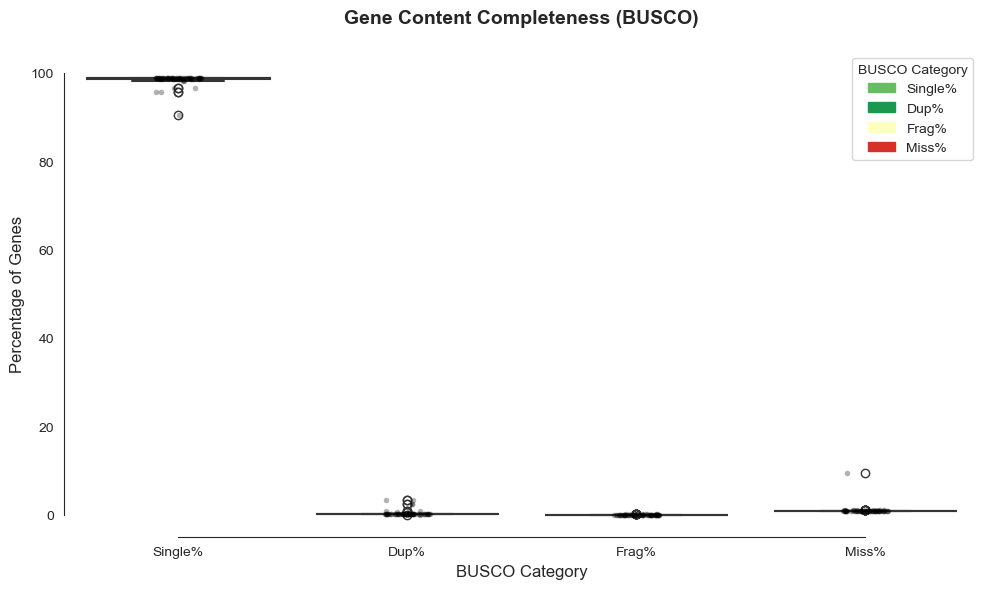

In [67]:
# Melt
busco_melt = df_busco.melt(
    id_vars=['Sample'],
    value_vars=['Single%', 'Dup%', 'Frag%', 'Miss%'],
    var_name='Category', value_name='Percentage'
)

# Colors
busco_colors = {
    'Single%': '#66BD63', # Light Green
    'Dup%': '#1A9850',    # Dark Green
    'Frag%': '#FFFFBF',   # Yellow
    'Miss%': '#D73027'    # Red
}

plt.figure(figsize=(10, 6))

# Boxplot
ax = sns.boxplot(
    data=busco_melt,
    x='Category',
    y='Percentage',
    hue='Category', # Explicitly mapping x to hue
    palette=busco_colors,
    dodge=False, # standard boxplot behavior
    linewidth=1.5
)

# Stripplot for points
sns.stripplot(
    data=busco_melt,
    x='Category',
    y='Percentage',
    color='black',
    alpha=0.3,
    size=4,
    jitter=True,
    ax=ax,
    legend=False # No legend for points
)

# Aesthetics
ax.grid(False) # No grid
sns.despine(trim=True) # Cleaner look

# MANUAL LEGEND creation to avoid "No legend attached" error
handles = []
for cat, color in busco_colors.items():
    patch = mpatches.Patch(color=color, label=cat)
    handles.append(patch)

# Add the manual legend
ax.legend(handles=handles, title='BUSCO Category', loc='upper right')

plt.title('Gene Content Completeness (BUSCO)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('BUSCO Category', fontsize=12)
plt.ylabel('Percentage of Genes', fontsize=12)
plt.ylim(-5, 105)

plt.tight_layout()
plt.savefig('Figure_BUSCO_Boxplot_Fixed.png', dpi=300)
print("Figure_BUSCO_Boxplot_Fixed.png generated.")

In [69]:
df_busco

,Sample,Lineage,Complete%,Single%,Dup%,Frag%,Miss%,Total
0,GCA_007742535.1,enterobacterales_odb10,99.1,98.9,0.2,0.0,0.9,440
1,GCA_009624535.1,enterobacterales_odb10,99.1,98.9,0.2,0.0,0.9,440
2,GCA_009227165.1,enterobacterales_odb10,99.1,98.9,0.2,0.0,0.9,440
3,GCA_006683205.1,enterobacterales_odb10,99.1,98.9,0.2,0.0,0.9,440
4,GCA_041411215.1,enterobacterales_odb10,99.1,98.9,0.2,0.0,0.9,440
...,...,...,...,...,...,...,...,...
60,GCA_006076875.1,enterobacterales_odb10,99.1,98.9,0.2,0.0,0.9,440
61,GCA_002042015.1,enterobacterales_odb10,98.8,98.6,0.2,0.2,1.0,440
62,GCA_002041695.1,enterobacterales_odb10,98.8,98.6,0.2,0.2,1.0,440
63,GCA_008003705.1,enterobacterales_odb10,99.1,98.9,0.2,0.0,0.9,440
